In [31]:
import pandas as pd
import numpy as np
from hdr_adjustments import hdr_adjustment
import matplotlib.pyplot as plt
from skimage import io
from matplotlib.colors import ListedColormap, BoundaryNorm
from preprocess_point_cloud import preprocess_point_cloud
from pathlib import Path

## Initialize Input Paths

In [32]:
# filename = Path('C:/Users/fzhcis/Documents/mylab/tls_demo/demo_files/UMBCBL009_2024-03-28-02-47-26_ALRSET12_060180_000200.800_1830507489.txt')
# filename = Path('C:/Users/fzhcis/Documents/projects/from_RobC/for_Fei/data/palau_2024/AURSET2/UMBCBL009_2024-03-27-23-59-45_AURSET2North_060180_000116.799_1327754030.txt')
filename = Path(r'C:\Users\fzhcis\Documents\projects\from_RobC\for_Fei\data\palau_2024\ALRSET1\UMBCBL009_2024-03-28-02-47-26_ALRSET12_060180_000200.800_1830507489.txt')
saveflag = True

output_dir = './outputs'

In [33]:
AZIMUTH_NORM_SCALE = 360
ZENITH_NORM_SCALE = 135
# Since degree resolution=0.25: 360/0.25=1440
CANVAS_WIDTH = 1440 
CANVAS_HEIGHT = 540

## Preprocess the Point Cloud data
- read the data as a pandas dataframe
- Clean it
  - Filter with first return and non-extreme intensity values
- prepare x_pix and y_pix columns for grouping

## Prepare the functions for displaying images.

In [34]:
def display_unwrapped_images(subplot_images: tuple[np.ndarray], 
                             titles: tuple[str],
                             colormap: str = 'plasma', 
                             saveflag: bool = False) -> None:
    """
    Display two images with titles and colorbars.

    Parameters:
    subplot1_image (np.ndarray): The first image to display.
    subplot2_image (np.ndarray): The second image to display.
    title1 (str): Title for the first image.
    title2 (str): Title for the second image.
    colormap (str): Colormap to use for displaying the images. Default is 'plasma'.
    saveflag (bool): If True, save the images to the output_dir. Default is False.

    Returns:
    None
    """
    num_subplots = len(subplot_images)
    fig, axes = plt.subplots(num_subplots, 1, figsize=(12, 4*num_subplots))

    # Set the colormap to something more visually friendly
    colormap = colormap  # e.g.: 'jet', 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    aspect_ratio = CANVAS_HEIGHT / CANVAS_WIDTH

    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)

    for ax, subplot_img, title in zip(axes, subplot_images, titles):
        im = ax.imshow(subplot_img, cmap=colormap, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
        ax.set_xlabel('Azimuth Angle (degrees)')
        ax.set_ylabel('Zenith from Z (degree)')
        ax.set_xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
        ax.set_yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust colorbar size
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

    if saveflag:
        for i, title in enumerate(titles):
            plt.imsave(f'{output_dir}/{title}.png', subplot_images[i], cmap=colormap)
        
        fig.savefig(f'{output_dir}/combined_image.png')
        print(f'Images saved to {output_dir} directory')


### Observe the density map and histograms

In [35]:
def display_density_images(image_data: np.ndarray, saveflag: bool = False) -> None:
    """
    Display a density map image with a discrete colormap and optionally save the image.
    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    saveflag : bool, optional
        If True, the function will save the displayed image and the raw image data to the output_dir directory (default is False).
    Returns:
    --------
    None
    Notes:
    ------
    - The colormap used is 'jet' with the color for zero density set to black.
    - The colorbar is labeled with integer ticks corresponding to the density values.
    - If `saveflag` is True, two images are saved:
        1. 'Point Density Map raw.png' - the raw image data with the 'jet' colormap.
        2. 'Point Density Map.png' - the displayed image with a resolution of 600 dpi.
    """
    # Display the image with the discrete colormap
    fig = plt.figure(figsize=(12, 4))
    max_density = int(image_data.max())

    colors = plt.get_cmap('jet', max_density+1)(np.arange(max_density+1))
    colors[0] = [0, 0, 0, 1]  # Set the color for zero to black (RGBA)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, max_density+1.5, 1), cmap.N)  # Discrete boundaries at each integer
    
    plt.imshow(image_data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(ticks=range(max_density+1))  # Add colorbar with integer ticks
    cbar.set_ticklabels([str(i) for i in range(max_density+1)])  # Set labels to match each value
    cbar.set_label('Points per pixel')
    plt.title('Point Density Map')
    plt.show()

    if saveflag:
        plt.imsave(f'{output_dir}/Point Density Map raw.png', image_data, cmap=cmap)
        fig.savefig(f'{output_dir}/Point Density Map.png', dpi=600)
        print(f'Images saved to {output_dir} directory')


In [36]:
def get_image_histogram(image_data: np.ndarray, title: str = '', saveflag: bool = False) -> None:
    """
    Generate and display a histogram of pixel values in the image data.

    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    title : str
        Title of the histogram plot.
    saveflag : bool, optional
        If True, the function will save the histogram plot to the output_dir directory (default is False).

    Returns:
    --------
    None
    """
    # Flatten the data to get a 1D array of values
    flattened_data = image_data.flatten()

    # Get unique values and their counts
    unique_values = np.unique(flattened_data)
    
    # Determine the number of bins
    if len(unique_values) > 20:
        bins = 20  # Limit bins to 20 if there are more than 20 unique values
        hist_values, bin_edges = np.histogram(flattened_data, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        normalized_counts = hist_values / hist_values.sum()  # Normalize counts
    else:
        values, counts = np.unique(flattened_data, return_counts=True)
        hist_values = counts
        bin_centers = values
        normalized_counts = hist_values / hist_values.sum()  # Normalize counts

    # Create the bar plot
    fig, ax1 = plt.subplots()

    # Absolute count bars
    ax1.bar(bin_centers, hist_values, width=0.8 * (bin_centers[1] - bin_centers[0]) if len(bin_centers) > 1 else 1,
            color='blue', alpha=0.7, label='Absolute Count')
    ax1.set_xlabel('Pixel Value')
    ax1.set_ylabel('Absolute Count', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Add a second y-axis for normalized portion
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, normalized_counts, color='orange', marker='o', linestyle='-', label='Normalized Portion')
    ax2.set_ylabel('Normalized Portion', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Add grid, legend, and title
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.title(f'Histogram of {title}')
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

    fig.tight_layout()
    plt.show()
    print(f'Histogram:\nValues: {bin_centers}\nCounts: {hist_values}\nNormalized Counts: {normalized_counts.round(3)}')
    
    if saveflag:
        fig.savefig(f'{output_dir}/Histogram_{title}.png', dpi=300)
        print(f'Histogram saved to {output_dir} directory')


In [ ]:
def unwrap_point_cloud_to_2d_images(filename: str, hdr_method: str = 'clahe') -> tuple[pd.DataFrame, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel value with different kinds of scalar fields.
    Including density, intensity, range, and range-xy images.

    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    hdr_method (str): The HDR adjustment hdr_method to apply. Default is 'clahe'.
    saveflag (bool): If True, save the images to the output_dir directory. Default is True.

    Returns:
    df_filtered (pd.DataFrame): A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: A tuple containing the density image, adjusted intensity image, adjusted range image, and adjusted range-xy image.
    """
    # Step 5: Fill in the canvas pixels with scalar field values
    ## Preprocess the point cloud data
    df_filtered = preprocess_point_cloud(filename)
    grouped = df_filtered.groupby(['y_pix', 'x_pix'])

    ## Compute intensity and range per pixel. 
    ## Since less than 0.1% of the pixels contain more than one point, it doesn't matter if we use mean or max.
    group_intensity = grouped['Intensity'].mean()
    group_range = grouped['range1metres'].max()
    pts_per_pixel = grouped.size()
    z_value_per_pixel = grouped['Z'].mean().abs()
    
    range_x = grouped['X'].mean()
    range_y = grouped['Y'].mean()
    range_xy = np.sqrt(range_x**2 + range_y**2)

    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    z_value_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    intensity_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_xy_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)  # range in xy plane
    density_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(group_intensity.index.tolist())
    intensity_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_intensity.values
    range_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_range.values
    density_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = pts_per_pixel.values
    range_xy_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = range_xy.values
    z_value_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = z_value_per_pixel.values

    # Step 6: Apply HDR adjustment to intensity and range images
    intensity_image_adjusted = hdr_adjustment(intensity_image, method='clahe')
    range_image_adjusted = hdr_adjustment(range_image, method=hdr_method)
    range_xy_image_adjusted = hdr_adjustment(range_xy_image, method=hdr_method)
    z_value_image_adjusted = hdr_adjustment(z_value_image, method=hdr_method)

    output_images = (density_image, intensity_image_adjusted, 
                     range_image_adjusted, range_xy_image_adjusted, 
                     z_value_image_adjusted, intensity_image, 
                     range_image, range_xy_image, z_value_image)
   
    return df_filtered, output_images


## Run the above process
- display density map and density histogram
- display Intensity Map, Range Map, and Range-XY Map

c:\Users\fzhcis\Documents\mylab\tls_demo\tls_point_segmentation\preprocess_point_cloud.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['x_pix'] = ((df_filtered['azimuth'] / AZIMUTH_NORM_SCALE) * (CANVAS_WIDTH - 1)).astype(int)
c:\Users\fzhcis\Documents\mylab\tls_demo\tls_point_segmentation\preprocess_point_cloud.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['y_pix'] = (((ZENITH_NORM_SCALE - df_filtered['zenith']) / ZENITH_NORM_SCALE) * (CANVAS_HEIGHT - 1)).astype(int)
c:\

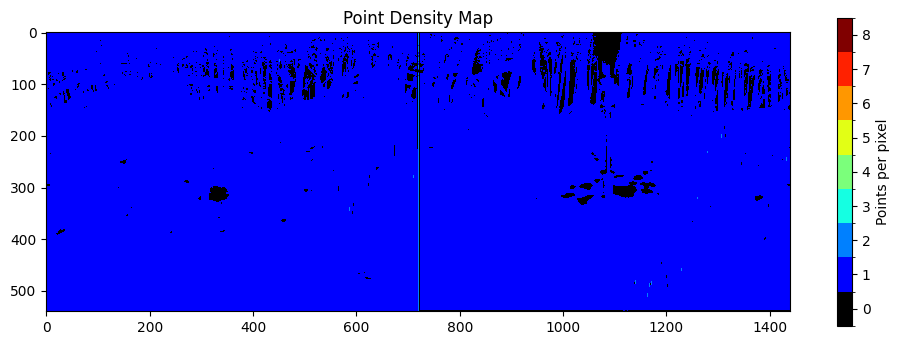

Images saved to ./outputs directory


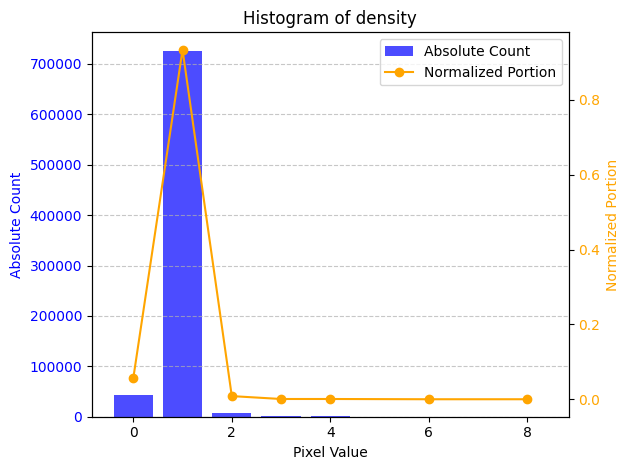

Histogram:
Values: [0. 1. 2. 3. 4. 6. 8.]
Counts: [ 43579 726422   6544    523    530      1      1]
Normalized Counts: [0.056 0.934 0.008 0.001 0.001 0.    0.   ]
Histogram saved to ./outputs directory


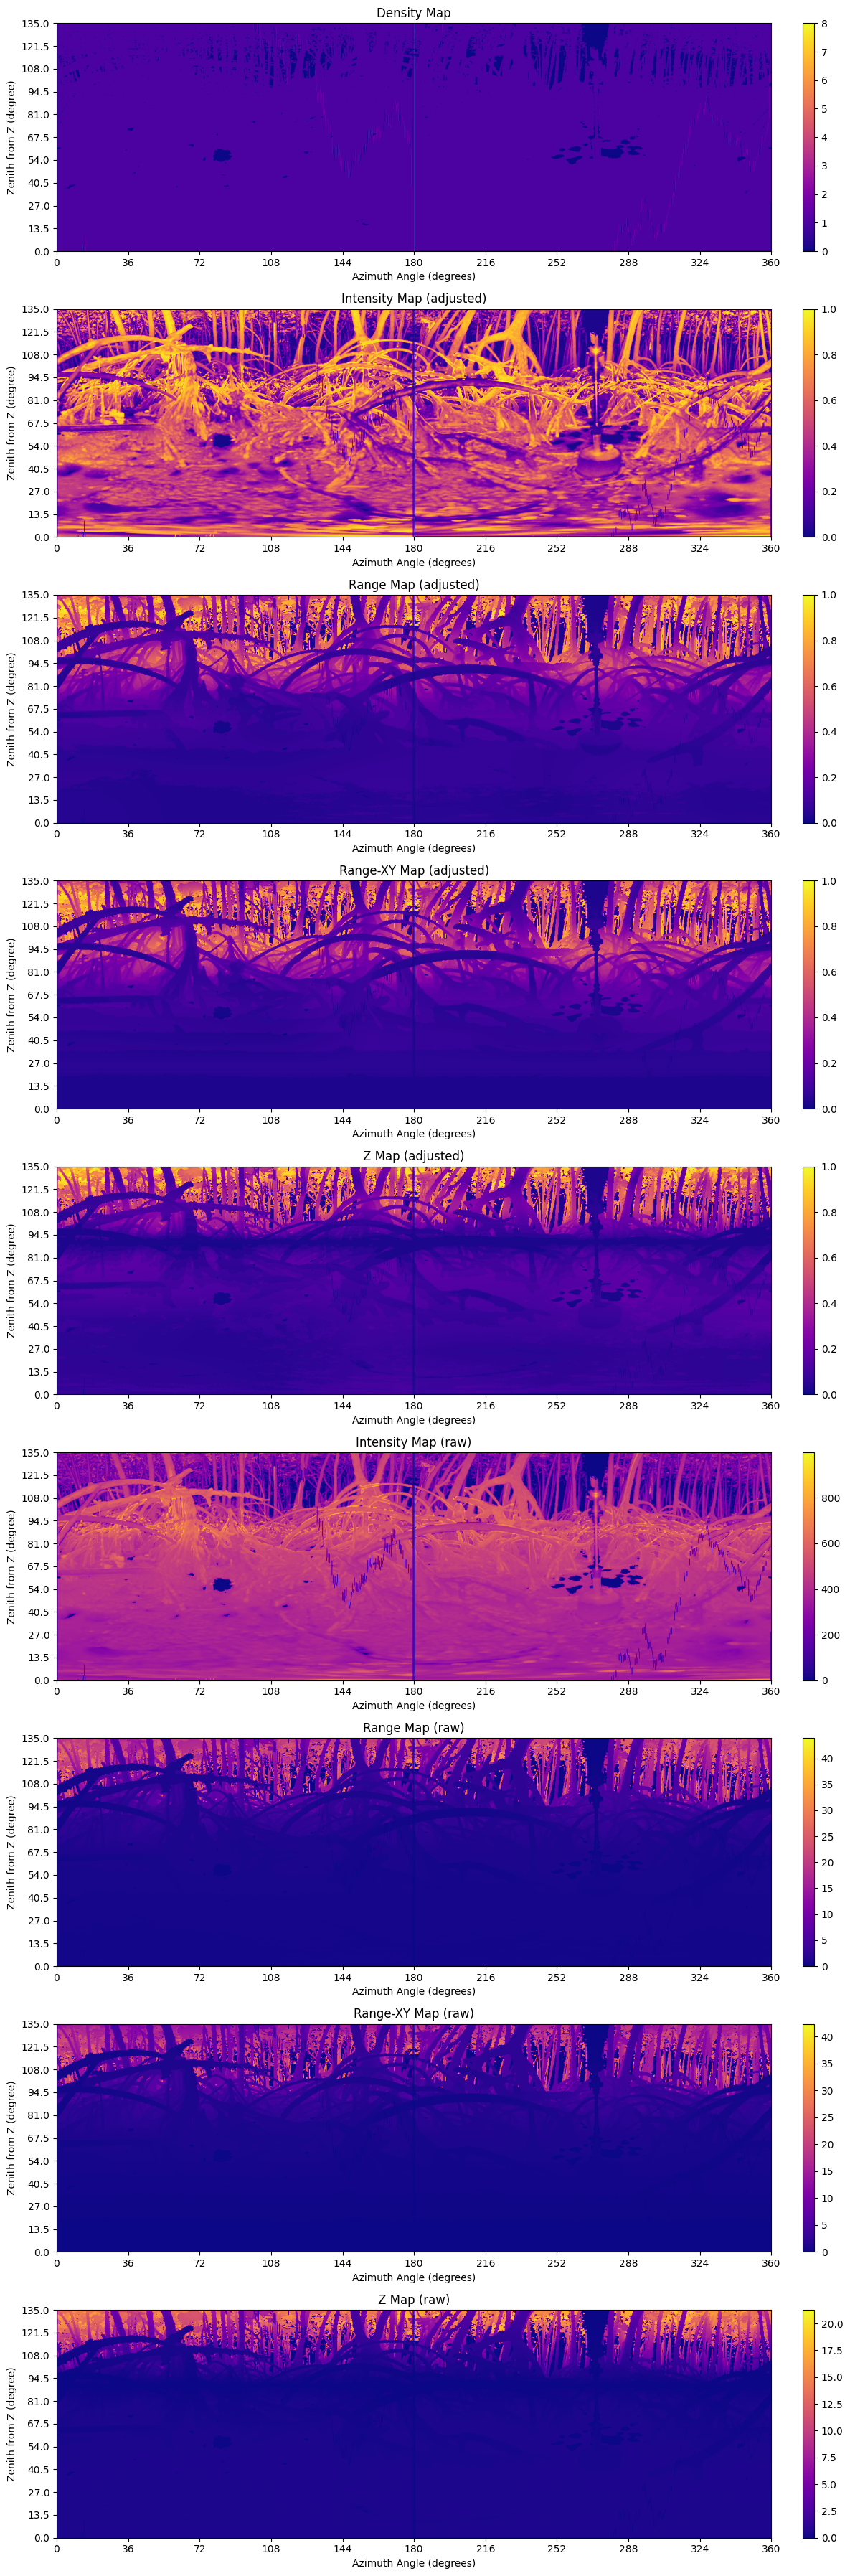

Images saved to ./outputs directory


In [38]:
df_filtered, output_images = unwrap_point_cloud_to_2d_images(filename, hdr_method='clahe')
density_image = output_images[0]
titles = ['Density Map', 'Intensity Map (adjusted)', 'Range Map (adjusted)', 'Range-XY Map (adjusted)', 'Z Map (adjusted)', 'Intensity Map (raw)', 'Range Map (raw)', 'Range-XY Map (raw)', 'Z Map (raw)']
display_density_images(density_image, saveflag=saveflag)
get_image_histogram(image_data=density_image, title='density', saveflag=saveflag)


# Step 7: Display and save the adjusted intensity and range images
display_unwrapped_images(output_images, 
                        titles=titles,
                        saveflag=saveflag)



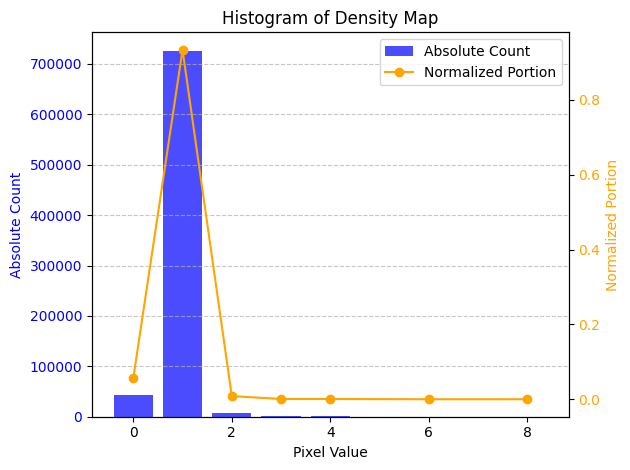

Histogram:
Values: [0. 1. 2. 3. 4. 6. 8.]
Counts: [ 43579 726422   6544    523    530      1      1]
Normalized Counts: [0.056 0.934 0.008 0.001 0.001 0.    0.   ]


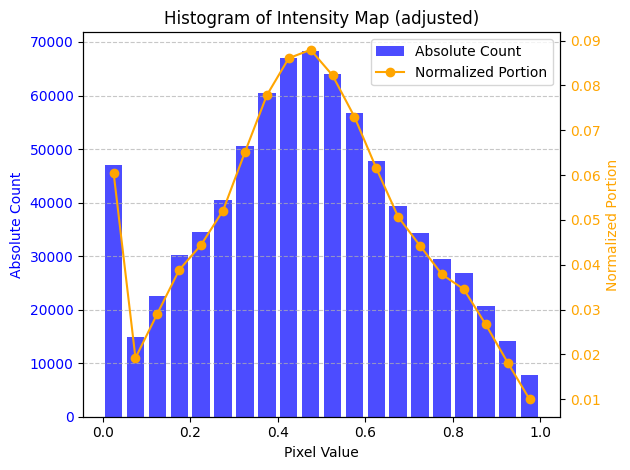

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [47079 14931 22625 30215 34561 40503 50629 60501 66925 68383 63961 56775
 47837 39394 34379 29424 26835 20735 14141  7767]
Normalized Counts: [0.061 0.019 0.029 0.039 0.044 0.052 0.065 0.078 0.086 0.088 0.082 0.073
 0.062 0.051 0.044 0.038 0.035 0.027 0.018 0.01 ]


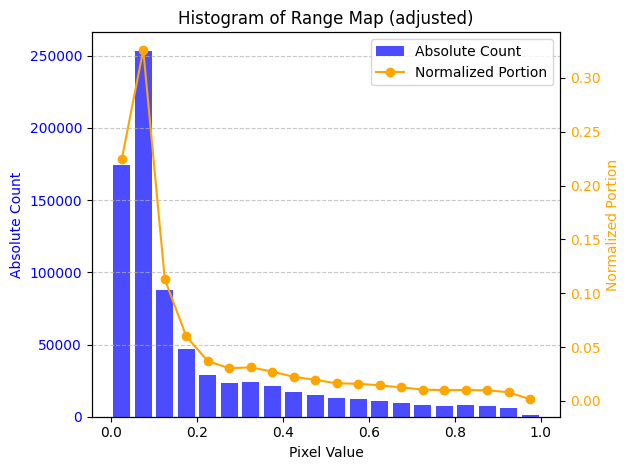

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [174595 253586  87998  46599  28760  23541  24205  21172  17345  15234
  12628  12382  11137   9775   8114   7719   7842   7604   6212   1152]
Normalized Counts: [0.225 0.326 0.113 0.06  0.037 0.03  0.031 0.027 0.022 0.02  0.016 0.016
 0.014 0.013 0.01  0.01  0.01  0.01  0.008 0.001]


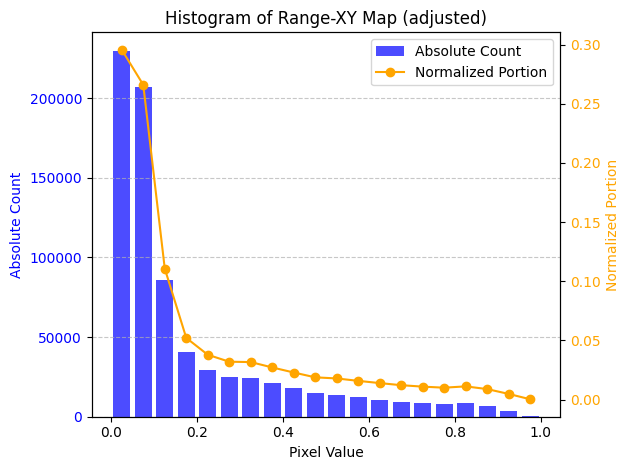

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [229855 206825  86092  40505  29429  24855  24614  21087  17760  14588
  13853  12273  10804   9423   8475   7776   8644   6871   3692    179]
Normalized Counts: [0.296 0.266 0.111 0.052 0.038 0.032 0.032 0.027 0.023 0.019 0.018 0.016
 0.014 0.012 0.011 0.01  0.011 0.009 0.005 0.   ]


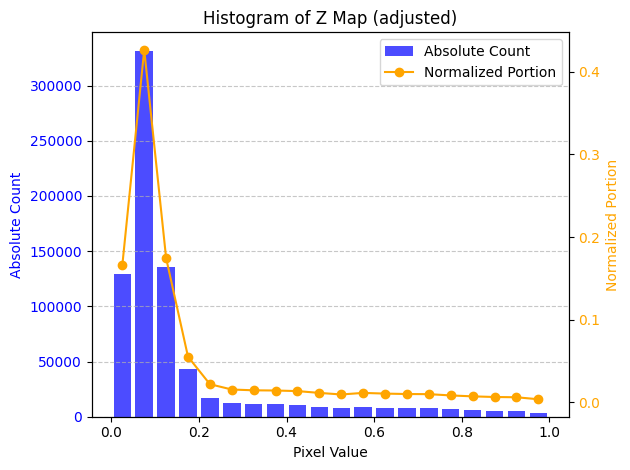

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [129229 331637 135770  43026  17189  12189  11442  11258  10704   9008
   7520   9013   8354   7945   7833   6624   5762   5151   4908   3038]
Normalized Counts: [0.166 0.426 0.175 0.055 0.022 0.016 0.015 0.014 0.014 0.012 0.01  0.012
 0.011 0.01  0.01  0.009 0.007 0.007 0.006 0.004]


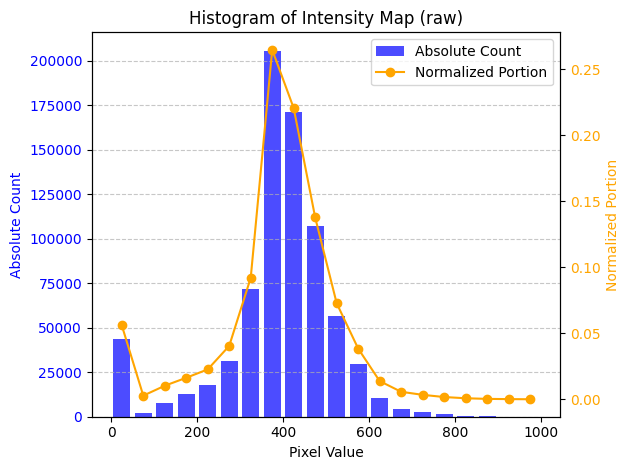

Histogram:
Values: [ 24.975    74.925   124.875   174.82501 224.775   274.725   324.675
 374.625   424.575   474.525   524.475   574.42505 624.375   674.32495
 724.275   774.225   824.17505 874.125   924.07495 974.025  ]
Counts: [ 43579   2144   7983  12670  17612  31451  71519 205743 171394 107025
  56533  29854  10730   4417   2622   1335    611    247    105     26]
Normalized Counts: [0.056 0.003 0.01  0.016 0.023 0.04  0.092 0.265 0.22  0.138 0.073 0.038
 0.014 0.006 0.003 0.002 0.001 0.    0.    0.   ]


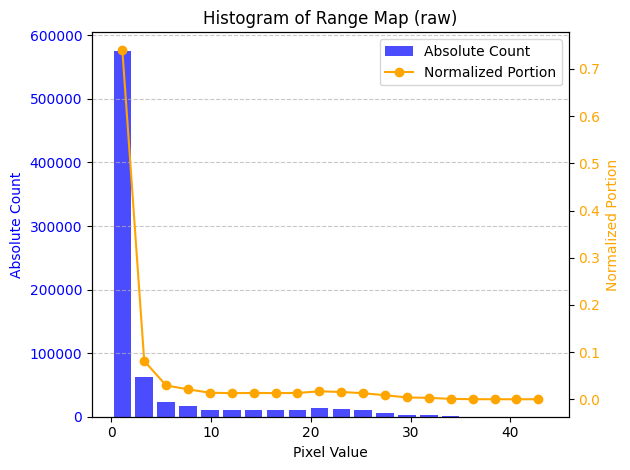

Histogram:
Values: [ 1.0973251  3.2919753  5.486625   7.6812754  9.875925  12.070576
 14.265225  16.459877  18.654526  20.849174  23.043827  25.238476
 27.433125  29.627777  31.822426  34.017075  36.211727  38.406376
 40.60103   42.795677 ]
Counts: [575881  63155  22797  16357  10722  10089  10324  10167  10357  13083
  11991   9955   6634   2967   2311    649    101     51      3      6]
Normalized Counts: [0.741 0.081 0.029 0.021 0.014 0.013 0.013 0.013 0.013 0.017 0.015 0.013
 0.009 0.004 0.003 0.001 0.    0.    0.    0.   ]


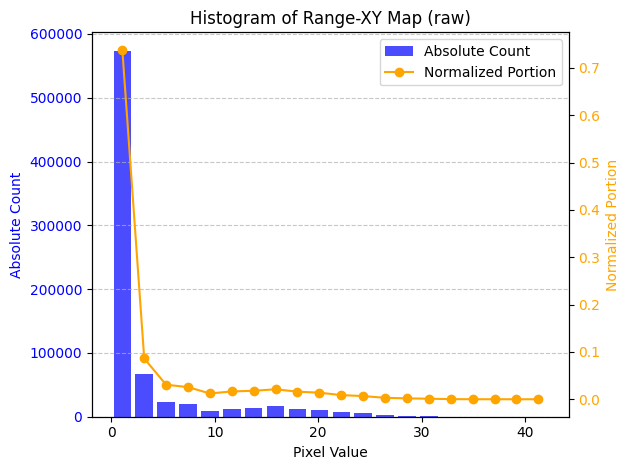

Histogram:
Values: [ 1.0586852  3.1760554  5.293426   7.410796   9.528167  11.645537
 13.762908  15.880278  17.997648  20.115019  22.23239   24.34976
 26.46713   28.584501  30.70187   32.81924   34.93661   37.05398
 39.171352  41.288723 ]
Counts: [573896  66935  23851  19946   9501  12851  13921  16339  12470  10817
   6813   5237   2369   1465    878    209     57     34      5      6]
Normalized Counts: [0.738 0.086 0.031 0.026 0.012 0.017 0.018 0.021 0.016 0.014 0.009 0.007
 0.003 0.002 0.001 0.    0.    0.    0.    0.   ]


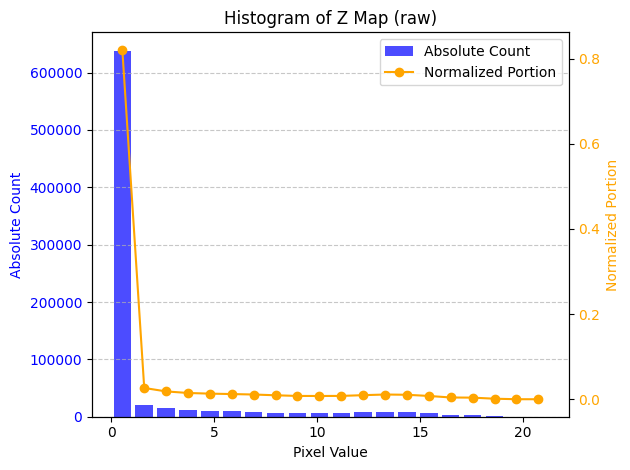

Histogram:
Values: [ 0.53183424  1.5955027   2.6591713   3.7228398   4.7865086   5.850177
  6.9138455   7.977514    9.0411825  10.104851   11.16852    12.232188
 13.295856   14.359526   15.423194   16.486862   17.55053    18.6142
 19.677868   20.741535  ]
Counts: [638211  20708  14408  11551  10337   9585   8730   7352   6129   6076
   6193   7528   8731   8268   6112   3310   3038   1082    159     92]
Normalized Counts: [0.821 0.027 0.019 0.015 0.013 0.012 0.011 0.009 0.008 0.008 0.008 0.01
 0.011 0.011 0.008 0.004 0.004 0.001 0.    0.   ]


In [39]:
# titles = ['density_image', 'intensity_image_adjusted', 'range_image_adjusted', 'range_xy_image_adjusted', 'intensity_image', 'range_image', 'range_xy_image']
for hist_image, title in zip(output_images, titles):
    get_image_histogram(image_data=hist_image, title=title, saveflag=False)

## Combine Unwrapped images to an psudo-RGB image

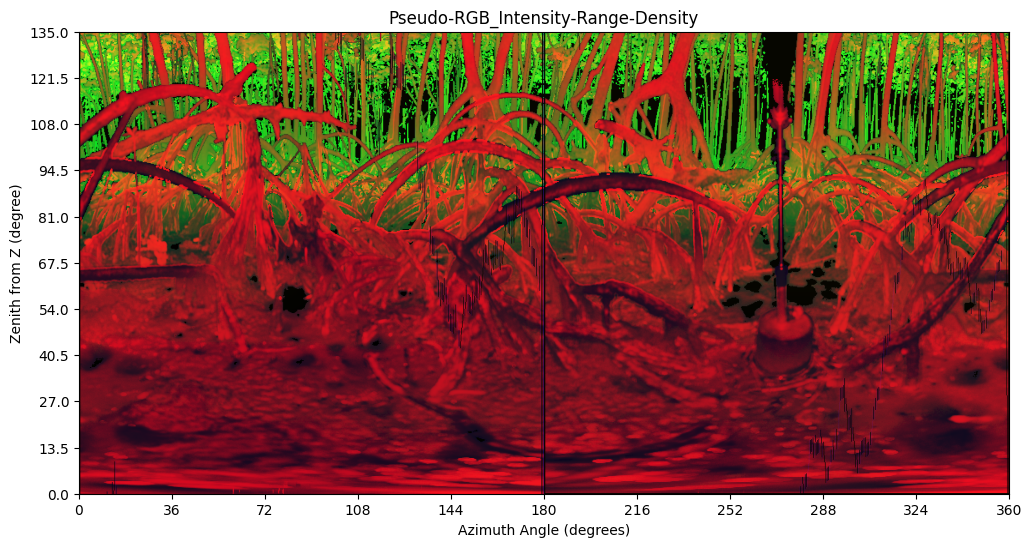

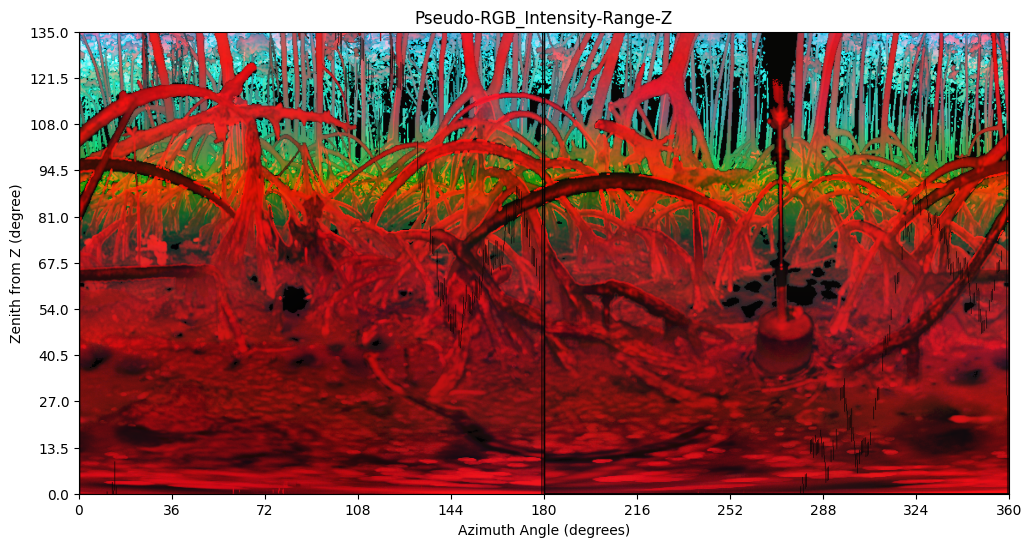

In [40]:
def create_pseudo_rgb_image(intensity_image: np.ndarray, 
                            range_image: np.ndarray, 
                            third_channel_img: np.ndarray, 
                            figure_title: str = '',
                            saveflag:bool=False) -> np.ndarray:
    """
    Combine intensity, range, and density images into a pseudo-RGB image.

    Parameters:
    -----------
    intensity_image : np.ndarray
        The adjusted intensity image.
    range_image : np.ndarray
        The adjusted range image.
    third_channel_img : np.ndarray
        The third channel image, can be the density map, z-value map, or any other scalar field.

    Returns:
    --------
    np.ndarray
        The pseudo-RGB image.
    """
    # Normalize the images to the range [0, 1]
    intensity_norm = (intensity_image - intensity_image.min()) / (intensity_image.max() - intensity_image.min())
    range_norm = (range_image - range_image.min()) / (range_image.max() - range_image.min())
    third_channel_img_norm = (third_channel_img - third_channel_img.min()) / (third_channel_img.max() - third_channel_img.min())

    # Stack the normalized images to create an RGB image
    # pseudo_rgb_image = np.stack((intensity_norm, range_norm, density_norm), axis=-1)
    pseudo_rgb_image = np.stack((intensity_norm, range_norm, third_channel_img_norm), axis=-1)

    # Display the pseudo-RGB image
    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(pseudo_rgb_image, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
    
    plt.title(figure_title)
    plt.xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
    plt.yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
    plt.xlabel('Azimuth Angle (degrees)')
    plt.ylabel('Zenith from Z (degree)')
    plt.show()

    if saveflag:
        pseudo_rgb_image_uint8 = (pseudo_rgb_image * 255).astype(np.uint8)
        io.imsave(f'{output_dir}/{figure_title}.tif', pseudo_rgb_image_uint8)

    return pseudo_rgb_image

# Create the pseudo-RGB image
figure_title_1 = 'Pseudo-RGB_Intensity-Range-Density'
figure_title_2 = 'Pseudo-RGB_Intensity-Range-Z'
density_image, intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted = output_images[0], output_images[1], output_images[2], output_images[4]
pseudo_rgb_image_1 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, density_image, figure_title_1, saveflag=saveflag)
pseudo_rgb_image_2 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, z_value_image_adjusted, figure_title_2, saveflag=saveflag)

